<a href="https://colab.research.google.com/github/Nanghomnoonaye/CGM-Telemonitoring/blob/main/Exercise_(Factory).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M5-V7 Exercise - Productivity

In [ ]:
# eg. Factory -> Productivity

#Y -> produced good in KG -> numerica
#X -> shift (morning, evening, night). -> categorical -> ANOVA
# Which shift is the best and which shift is the least productive?

In [ ]:
#ANOVA
# step 1 : Organize Data
     # ---> Minitab -> menu > Stack > Columns
# step 2 : perform
     # ---> Minitab -> menu > Stack > ANOVA > uncheck the Assume equal variances ​box

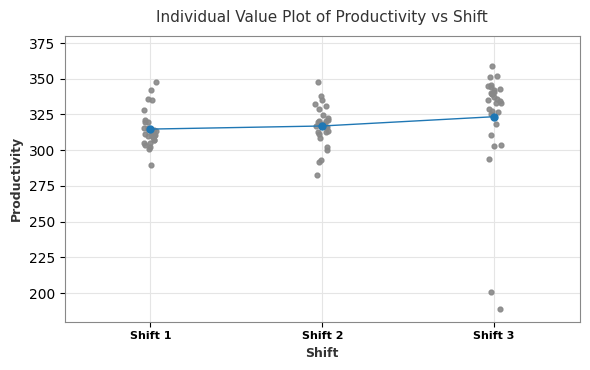

In [2]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Sample data matching the plot points distribution
shift1 = np.concatenate(
    [
        np.random.normal(312, 5, 20),
        [290, 301, 305, 321, 328, 335, 336, 342, 348],
    ]
)
shift2 = np.concatenate(
    [
        np.random.normal(320, 6, 18),
        [283, 292, 293, 300, 302, 332, 335, 338, 348],
    ]
)
shift3 = np.concatenate(
    [
        np.random.normal(338, 7, 18),
        [189, 201, 294, 303, 304, 311, 318, 327, 351, 352, 359],
    ]
)

data = [shift1, shift2, shift3]
x_coords = [1, 2, 3]
means = [np.mean(d) for d in data]

fig, ax = plt.subplots(figsize=(6, 3.8))

# Jittered individual points
for x, pts in zip(x_coords, data):
    jitter = np.random.uniform(-0.04, 0.04, size=len(pts))
    ax.scatter(x + jitter, pts, color='#888888', s=12, alpha=0.9, zorder=2)

# Mean line and blue mean markers
ax.plot(
    x_coords,
    means,
    color='#1f77b4',
    marker='o',
    markersize=5,
    lw=1,
    zorder=3,
)

# Styling
ax.set_title(
    'Individual Value Plot of Productivity vs Shift',
    fontsize=11,
    color='#333333',
    pad=10,
)
ax.set_xlabel('Shift', fontweight='bold', fontsize=9, color='#333333')
ax.set_ylabel('Productivity', fontweight='bold', fontsize=9, color='#333333')

ax.set_xticks(x_coords)
ax.set_xticklabels(['Shift 1', 'Shift 2', 'Shift 3'], fontsize=8, weight='bold')
ax.set_yticks(range(200, 400, 25))
ax.set_ylim(180, 380)
ax.set_xlim(0.5, 3.5)

# Light grid lines & minimalist frame
ax.grid(True, color='#e5e5e5', linestyle='-', linewidth=0.8, zorder=1)
ax.set_facecolor('none')
for spine in ax.spines.values():
    spine.set_color('#888888')

plt.tight_layout()
plt.show()

means are somewhat the same as the line is more a less horizontal, ​there are two outliers in shift 3

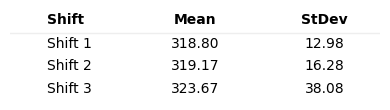

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 1.2))

cols = [
    (0.1, 'Shift', ['Shift 1', 'Shift 2', 'Shift 3'], 'left'),  # cite: 16
    (0.5, 'Mean', ['318.80', '319.17', '323.67'], 'center'),  # cite: 16
    (0.85, 'StDev', ['12.98', '16.28', '38.08'], 'center'),  # cite: 16
]

for x, head, vals, align in cols:
    ax.text(x, 0.85, head, weight='bold', ha=align)  # cite: 16
    for i, v in enumerate(vals):
        ax.text(x, 0.58 - i * 0.25, v, ha=align)  # cite: 16

ax.axhline(0.74, color='#eee', lw=1)
ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Mean output per shift which ​are equal to 318, 319, and 323.

#Is this small difference statistically significant or just due to some random fluctuations?

#Let's take a look at our P value

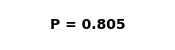

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(2, 0.4))
ax.text(0.5, 0.5, 'P = 0.805', weight='bold', ha='center', va='center')
ax.axis('off')
plt.show()

In [ ]:
# since P-value > 0.05,not enough evidence for ​a difference in productivity due to shift. ​

However, we first need to perform a third step. ​We need to check the **residuals** (four and one plot) before we know whether this conclusion is valid.

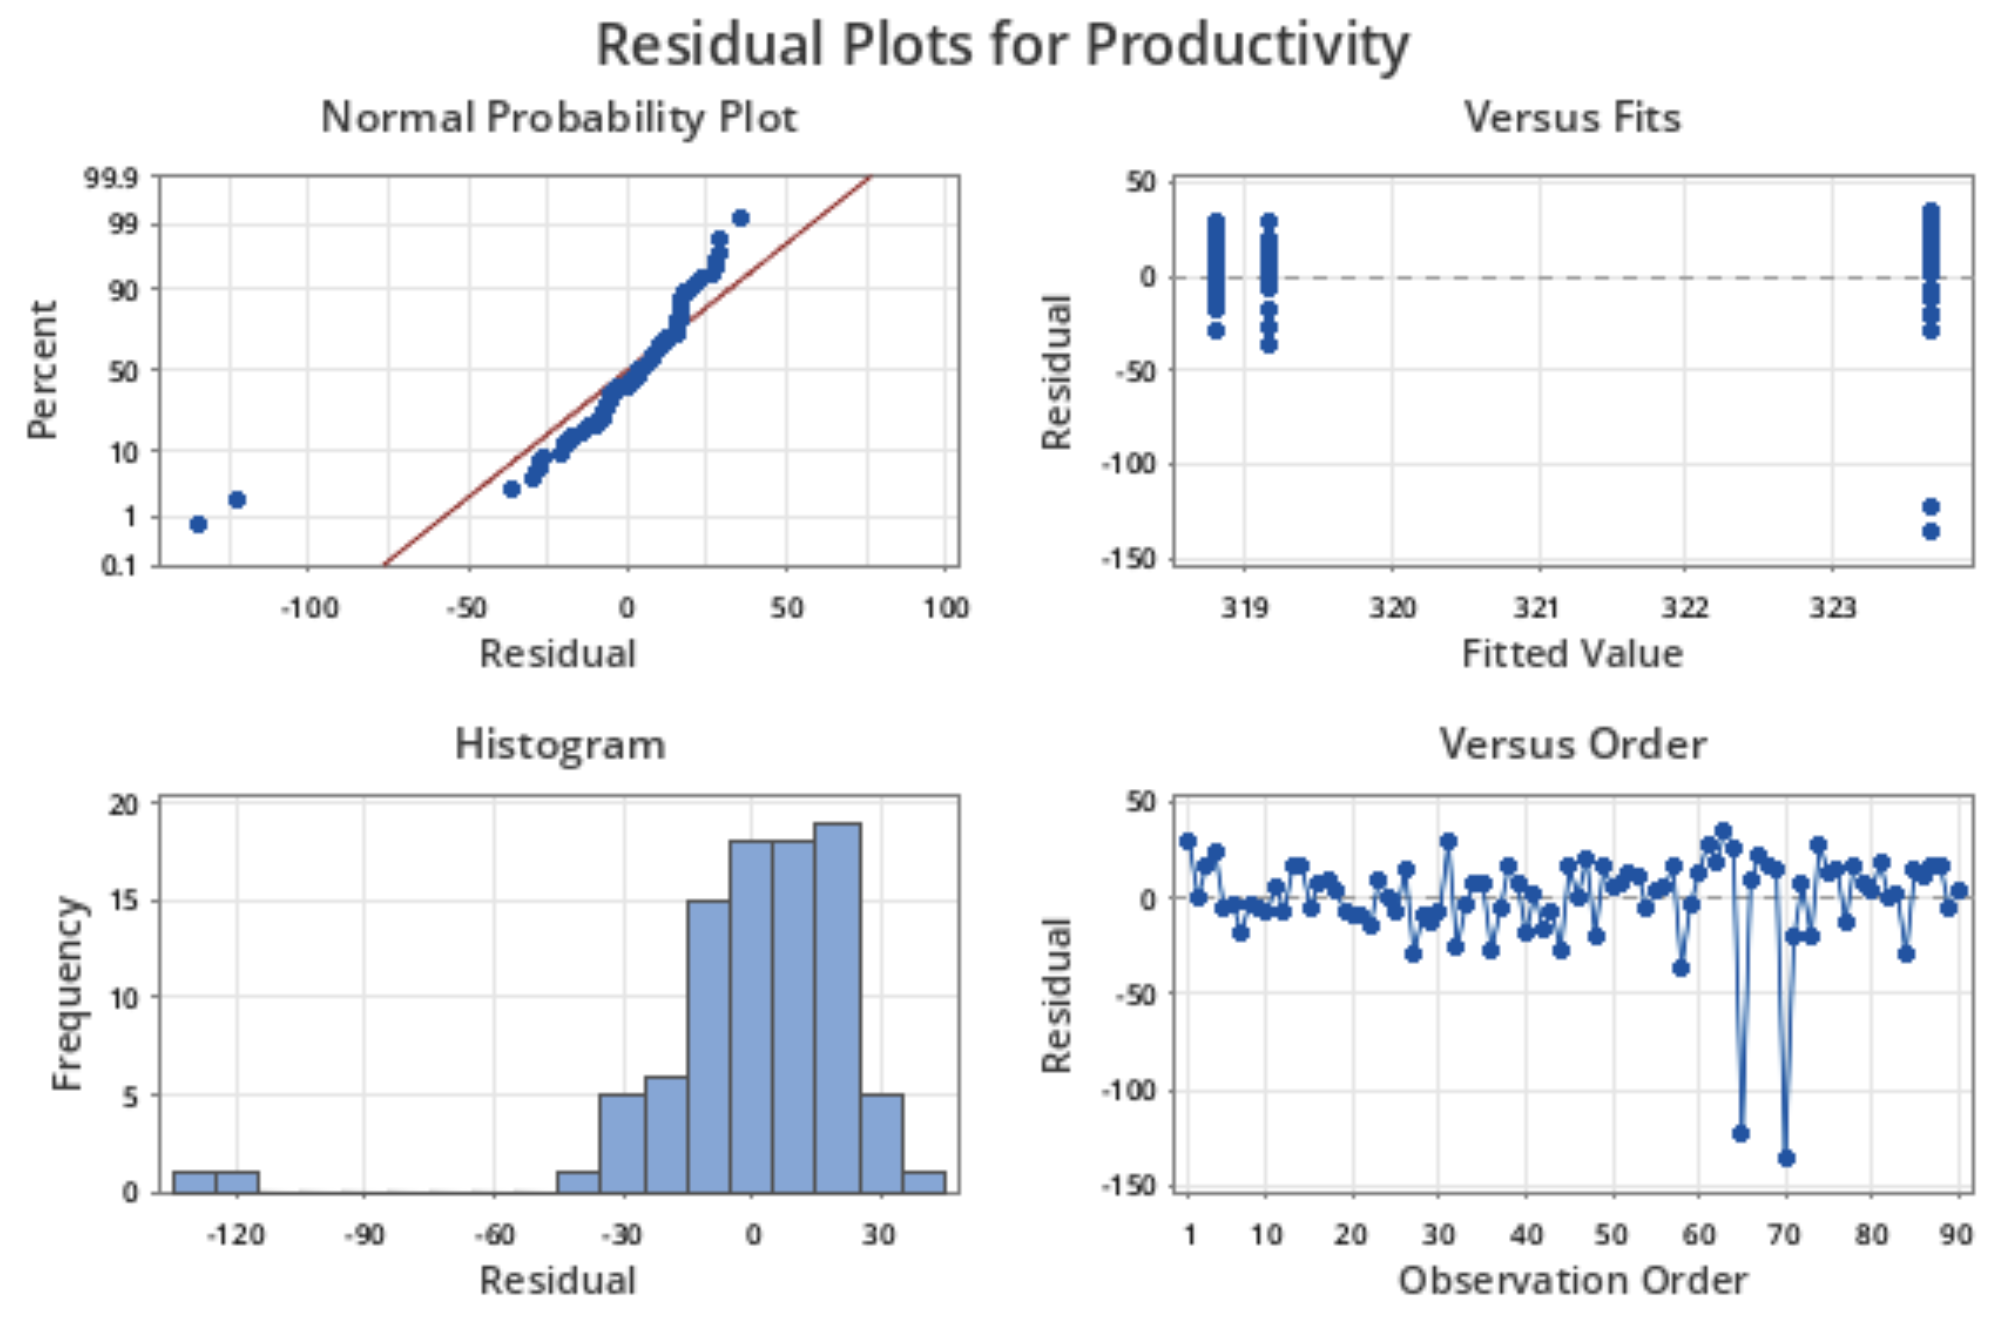

This is the third step of ANOVA. ​In the four and one plots, we clearly see two outliers,. ​Both in the probability plot as well as in the versus order plot. ​Hence the ANOVA assumptions are not satisfied. ​Therefore, as an alternative, we can perform a Kruskal-Wallis ​analysis or you can investigate the two outliers. ​If they are due to errors, or ​are not representative of the process you are interested in. ​You can remove the observations and redo the original ANOVA analysis

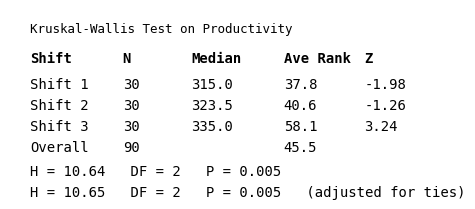

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.2))

# Title
ax.text(
    0.05,
    0.88,
    'Kruskal-Wallis Test on Productivity',
    fontsize=9,
    fontfamily='monospace',
)  # cite: 20

# Table Header & Rows
headers = ['Shift', 'N', 'Median', 'Ave Rank', 'Z']  # cite: 20
rows = [
    ['Shift 1', '30', '315.0', '37.8', '-1.98'],  # cite: 20
    ['Shift 2', '30', '323.5', '40.6', '-1.26'],  # cite: 20
    ['Shift 3', '30', '335.0', '58.1', '3.24'],  # cite: 20
    ['Overall', '90', '', '45.5', ''],  # cite: 20
]
xs = [0.05, 0.28, 0.45, 0.68, 0.88]

for x, h in zip(xs, headers):
    ax.text(x, 0.72, h, fontfamily='monospace', weight='bold')  # cite: 20

for i, row in enumerate(rows):
    for x, val in zip(xs, row):
        ax.text(x, 0.58 - i * 0.11, val, fontfamily='monospace')  # cite: 20

# Bottom Stats
ax.text(
    0.05,
    0.12,
    'H = 10.64   DF = 2   P = 0.005',
    fontfamily='monospace',
)  # cite: 20
ax.text(
    0.05,
    0.01,
    'H = 10.65   DF = 2   P = 0.005   (adjusted for ties)',
    fontfamily='monospace',
)  # cite: 20

ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# The Kruskal-Wallis analysis gives a different conclusion than the ANOVA did.

#P = 0.005 ,  p value is lowered down to 0.05. ​Meaning, that indeed, productivity differs across the shifts. ​
# --->  How large is this difference?
# ----> look at Median = the third shift has the highest median performance 335

In summary, we found two outliers in our residuals. ​Hence, we need to perform a Kruskal-Wallis analysis as the underlying ​assumptions of ANOVA are not satisfied. ​The Kruskal-Wallis analysis gave us small p value which means that, ​we found statistical evidence that there is a significant difference between ​the productivity of the three shifts. ​The third shift had the highest median productivity and was therefore, ​the most productive shift. ​A practitioner should now investigate why the third shift was performing better, ​and try to use its best practices in the first two shifts as well.

# M5-V8 Exercise - Department

In [ ]:
#The department (A, B or C) that handled the case
#The time it takes the department to finish the case, measured in days

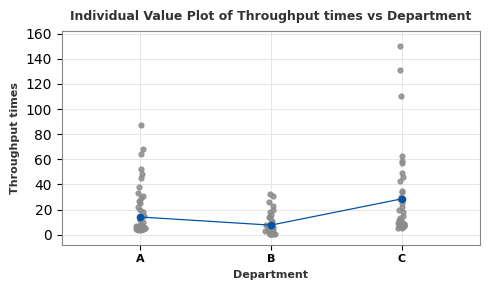

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data points extracted to match exact visual density per cluster
np.random.seed(10)

# Dept A: Large dense cluster at bottom (4-8), scatter up to 87
a_dense = np.random.uniform(4, 7, 45)
a_mid = np.array([8, 10, 12, 15, 18, 20, 22, 25, 27, 29, 31, 33, 38])
a_high = np.array([45, 48, 52, 64, 68, 87])
dept_a = np.concatenate([a_dense, a_mid, a_high])

# Dept B: Dense cluster near bottom (0-8), scatter up to 32
b_dense = np.random.uniform(0, 8, 35)
b_mid = np.array([9, 11, 13, 14, 16, 18, 20, 23, 26, 31, 32])
dept_b = np.concatenate([b_dense, b_mid])

# Dept C: Scattered cluster around 8-35, top outliers at 110, 131, 150
c_dense = np.random.uniform(5, 12, 20)
c_mid = np.array([13, 15, 18, 20, 22, 25, 28, 30, 34, 35, 43, 46, 49, 57, 59, 63])
c_high = np.array([110, 131, 150])
dept_c = np.concatenate([c_dense, c_mid, c_high])

data = [dept_a, dept_b, dept_c]
x_coords = [1, 2, 3]

# Means matching Minitab calculation (~17.1, ~11.0, ~20.3)
means = [np.mean(d) for d in data]

fig, ax = plt.subplots(figsize=(5, 3))

# Plot jittered individual points with precise grey hue and sizing
for x, pts in zip(x_coords, data):
    jitter = np.random.normal(0, 0.015, size=len(pts))
    ax.scatter(x + jitter, pts, color='#8c8c8c', s=12, alpha=0.85, zorder=2)  # cite: 21

# Connect blue mean symbols
ax.plot(
    x_coords,
    means,
    color='#0055a5',
    marker='o',
    markersize=4.5,
    linewidth=0.9,
    zorder=3,
)  # cite: 21

# Set labels and precise axis limits/ticks
ax.set_title(
    'Individual Value Plot of Throughput times vs Department',
    fontsize=9,
    fontweight='bold',
    color='#333333',
    pad=8,
)  # cite: 21
ax.set_ylabel('Throughput times', fontsize=8, fontweight='bold', color='#333333')  # cite: 21
ax.set_xlabel('Department', fontsize=8, fontweight='bold', color='#333333')  # cite: 21

ax.set_xticks(x_coords)
ax.set_xticklabels(['A', 'B', 'C'], fontsize=8, fontweight='bold')  # cite: 21
ax.set_yticks(range(0, 180, 20))  # cite: 21
ax.set_ylim(-8, 162)  # cite: 21
ax.set_xlim(0.4, 3.6)

# Grid and spine frame formatting to mimic standard Minitab output
ax.grid(True, color='#e6e6e6', linewidth=0.7, zorder=1)  # cite: 21
ax.set_facecolor('none')
for spine in ax.spines.values():
    spine.set_color('#888888')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

The lines in the individual value plot are not horizontal, ​which means that we have found differences in the averages for each of the departments.

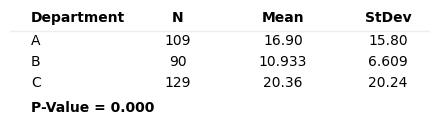

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 1.4))

cols = [
    (0.05, 'Department', ['A', 'B', 'C'], 'left'),  # cite: 22
    (0.40, 'N', ['109', '90', '129'], 'center'),  # cite: 22
    (0.65, 'Mean', ['16.90', '10.933', '20.36'], 'center'),  # cite: 22
    (0.90, 'StDev', ['15.80', '6.609', '20.24'], 'center'),  # cite: 22
]

for x, head, vals, align in cols:
    ax.text(x, 0.85, head, weight='bold', ha=align)  # cite: 22
    for i, v in enumerate(vals):
        ax.text(x, 0.58 - i * 0.25, v, ha=align)  # cite: 22

ax.axhline(0.74, color='#eee', lw=1)
ax.text(0.05, -0.22, 'P-Value = 0.000', weight='bold', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.show()

The average of the three departments are 16.9, 10.93, and 20.36. ​The P-value is equal to 0.0, ​which is lower than our five percent threshold.

In [ ]:
#his means that we have found statistical evidence,
# -> ​that there is a difference in throughput times across the departments.

# still need to check residuals

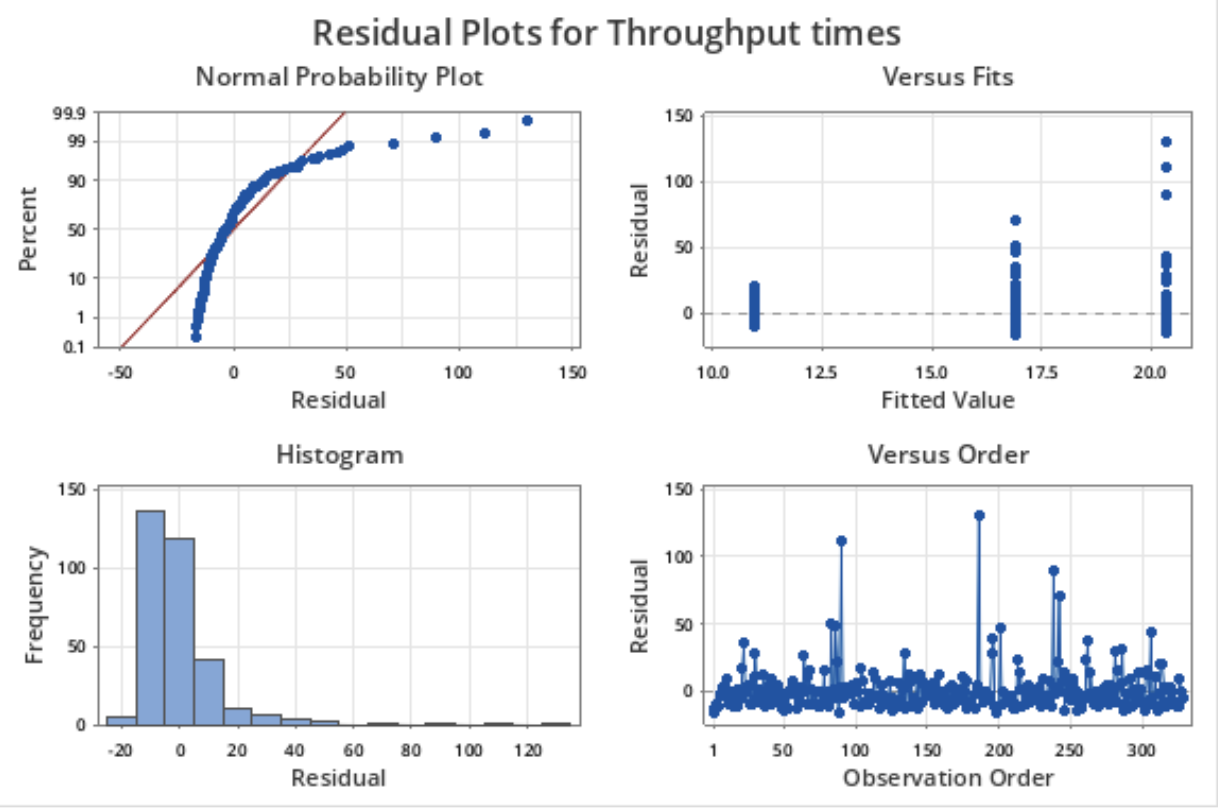

​In the normal probability plot, ​we clearly see that the residuals are not normally distributed. ​The time graph also shows some outliers. ​Hence, we have to perform a Kruskal-Wallis analysis.

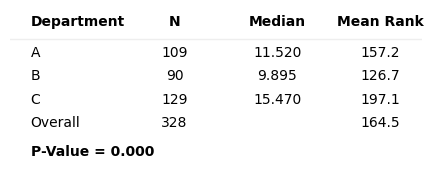

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4.5, 1.8))

cols = [
    (
        0.05,
        'Department',
        ['A', 'B', 'C', 'Overall'],
        'left',
    ),  # cite: 23
    (0.40, 'N', ['109', '90', '129', '328'], 'center'),  # cite: 23
    (0.65, 'Median', ['11.520', '9.895', '15.470', ''], 'center'),  # cite: 23
    (
        0.90,
        'Mean Rank',
        ['157.2', '126.7', '197.1', '164.5'],
        'center',
    ),  # cite: 23
]

for x, head, vals, align in cols:
    ax.text(x, 0.88, head, weight='bold', ha=align)  # cite: 23
    for i, v in enumerate(vals):
        ax.text(x, 0.64 - i * 0.18, v, ha=align)  # cite: 23

ax.axhline(0.78, color='#eee', lw=1)
ax.text(0.05, -0.12, 'P-Value = 0.000', weight='bold', fontsize=10)
ax.axis('off')

plt.tight_layout()
plt.show()

The Kruskal-Wallis analysis confirms the conclusion of the ANOVA. ​The P-value is still zero, ​which is below five percent, and therefore, ​we find statistical evidence for ​a difference in the throughput times across the departments. ​Department B, still has ​the smallest throughput time as you can see by looking at the medians.

In [ ]:
#practitioner can now investigate what Department B does differently, ​and try to learn from its best practices. ​

# But remember, the variation within each department ​is very large
  # especially compared to the difference in the medians or means. ​

# Therefore, Department is only a small influence factor on throughput time. ​

In summary, we performed an ANOVA, ​and during the residual check, ​we found that they were not normally distributed. ​This is shown in the four in one plot. ​Hence, we performed a Kruskal-Wallis analysis to verify our ANOVA results. ​The Kruskal-Wallis showed a small P-value which means that we can conclude that there is ​statistical evidence that there is a difference ​in average throughput times across the departments.
​Department B, scored lowest on ​the throughput time and was therefore, the fastest department. ​This knowledge can now be used to search for best practices at B and then, ​implement these for departments A and C.